# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

## **Importing the necessary libraries and overview of the dataset**

In [423]:
# Library to suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [424]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# import libraries for data visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Library to extract datetime features
import datetime as dt


In [425]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Loading the dataset**

In [427]:
# read the data
data = pd.read_csv('foodhub_order.csv')

In [428]:
# Copying data to another variable to avoid any changes to the original data
df = data.copy()

## Understanding the structure of the data

### **View the first 5 rows of the dataset**

In [429]:

# Looking at head (the first 5 observations)
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **View the last 5 rows of the dataset**

In [430]:
# Looking at tail (the last 5 observations)
df.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


**Observations:**

* The DataFrame has 9 columns as mentioned in the Data Dictionary.
order_id,customer_id, restaurant_name, cuisine_type, cost_of_the_order, day_of_the_week, rating,food_preparation_time, delivery_time.

* The rating column has some values as 'Not given' instead of numerical values.

* day_of_the_week has only two strring values- Weekend, Weekday

* order_id column has values sequential order starting from 0 to 1897

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [431]:
df.shape

(1898, 9)



* The DataFrame has **1898 rows and 9 columns**.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [432]:
# print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


**Observations:**

* The DataFrame has 4 integer, 1 float and 4 object type columns.
* rating is an 'object data type'
* restaurant_name, cuisine_type, day_of_the_week should be categorical variables.

In [433]:
# counting the column types further to get the summary of the data
df.dtypes.value_counts()

,count
int64,4
object,4
float64,1


**Observations:**

* The DataFrame has 4 integer, 1 float and 4 object type columns.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [434]:
# Checking missing values
df.isna().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


**Observations:**

* The DataFrame has no missing values in any of the column.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [435]:
# Summary statistics of the numeric variables only
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


In [436]:
# summary of non-numeric variables.
df.describe(exclude = 'number').T

,count,unique,top,freq
restaurant_name,1898,178,Shake Shack,219
cuisine_type,1898,14,American,584
day_of_the_week,1898,2,Weekend,1351
rating,1898,4,Not given,736


**Observations:**

* Food Preparation Time: The mimimum time it takes to prepare the food is 20 min. The Maximum time it takes to prepare the food is 35 min and average time is 27.37 min. std deviation 4.6min

* Cost of the Order: The min value of an order is $4.74 to maximum $35.41. Average value of the ordered food is $16.5

* Cusine Type: There are 14 unique cuisine types. The most popular is "American".

* Restaurant Name: There are 178 unique restaurants in the dataset. The most frequent is "Shake Shack".

* Delivery Time: The average time it takes to deliver an order, is approximately 24.16 minutes. Std deviation of 4.9min. Delivery times range from a min of 15min to a maxi of 33min. IQR for the orders delivered between 20min and 28min.

* Rating: There are 4 unique rating values.  There are 736 oders that are given no rating, indicated by "Not given".

* Day of the week :A majority of the orders (1,351 out of 1,898) are placed on weekends.



### **Question 5:** How many orders are not rated? [1 mark]

In [437]:
# Filter the rating column data with 'Not given'
df[df['rating']=='Not given'].shape[0]

736

In [438]:
# findining the counts of each unique rating data
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


**Observations:**

* There are 736 orders that are not rated.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

**1. Order ID**

In [439]:
# value_counts provide the the unique data counts of order_id
df['order_id'].value_counts()
#alternately, nunique provies the number of unique order_id
df['order_id'].nunique()


1898

**Observations:**
* The order_id column has 1898 rows of unique Order IDs.

**2. Customer ID**

In [440]:
df['customer_id'].value_counts().T

,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7
...,...
143926,1
89574,1
157711,1


In [441]:
df['customer_id'].nunique()

1200

**Observations:**
* There are 1200 unique Customers in the app. Some customers have ordered food 13, 10, 9, 8, 7 times, and some only 1 time.

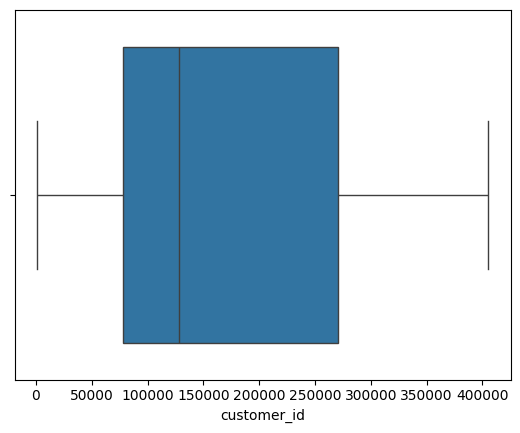

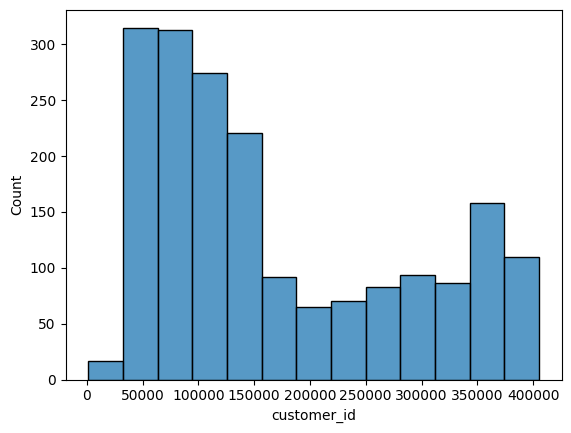

In [442]:
sns.boxplot(data=df, x='customer_id')
plt.show()
sns.histplot(data=df, x='customer_id')
plt.show()


**Observations:**

* The DataFrame has total 1200 unique Customers. Box plot Looks some what right skewed.

**3. Restaurent Name**

In [443]:
# counts of each unique restaurent names
df['restaurant_name'].value_counts()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68
...,...
Rye House,1
Hiroko's Place,1
Frank Restaurant,1


**Observations:**

* There are 178 unique Restaurents present in this DataFrame. Shake Shack is the most popular one because it received highest no of orders.


In [444]:
# top 10 unique restaurent names
df['restaurant_name'].value_counts().index[:10]

Index(['Shake Shack', 'The Meatball Shop', 'Blue Ribbon Sushi',
       'Blue Ribbon Fried Chicken', 'Parm', 'RedFarm Broadway',
       'RedFarm Hudson', 'TAO', 'Han Dynasty',
       'Blue Ribbon Sushi Bar & Grill'],
      dtype='object', name='restaurant_name')

**Observations:**

* Top 10 restaurents that received most orders are ['Shake Shack', 'The Meatball Shop', 'Blue Ribbon Sushi',
       'Blue Ribbon Fried Chicken', 'Parm', 'RedFarm Broadway',
       'RedFarm Hudson', 'TAO', 'Han Dynasty',
       'Blue Ribbon Sushi Bar & Grill']

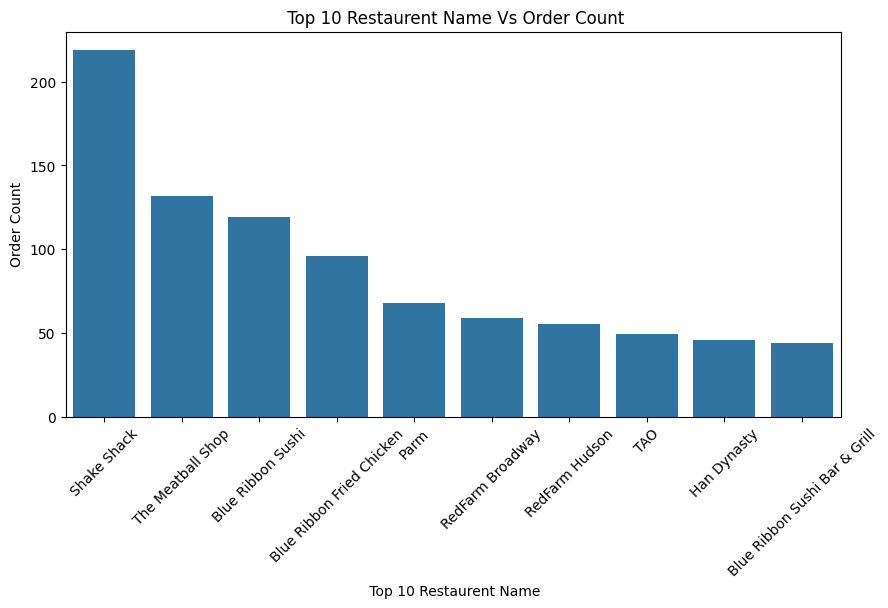

In [445]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='restaurant_name', order= df['restaurant_name'].value_counts().index[0:10])
plt.title(" Top 10 Restaurent Name Vs Order Count")
plt.xlabel(" Top 10 Restaurent Name")
plt.ylabel("Order Count")
plt.xticks (rotation=45)
plt.show()


**Observations:**

* The Weenend orders are larger than weekday orders.

*  Shake shack is the most popular restaurent with highest order  List item count.




**4. Cuisine Type**

In [446]:
## total no of unique cuisines
df['cuisine_type'].nunique()

14

* There are 14 different unique cuisine types present in the DataFrame

In [447]:
#count of each cuisnines
df['cuisine_type'].value_counts()

,count
cuisine_type,
American,584
Japanese,470
Italian,298
Chinese,215
Mexican,77
Indian,73
Middle Eastern,49
Mediterranean,46
Thai,19


**Observations:**

* Most popular cuisine type is American cuisne. Followed by Japanese, Italian, Chinese, Mexican, Indian etc..

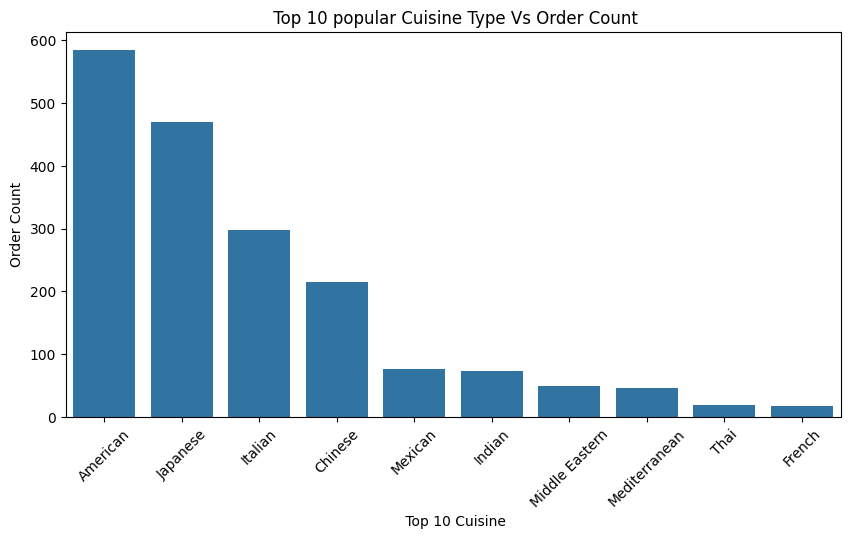

In [448]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='cuisine_type', order= df['cuisine_type'].value_counts().index[0:10])
plt.title(" Top 10 popular Cuisine Type Vs Order Count")
plt.xlabel(" Top 10 Cuisine")
plt.ylabel("Order Count")
plt.xticks (rotation=45)
plt.show()

**Observations:**

* The most popular cuisine type, regardless of the day of the week, is "American" followed by "Japanese", "Italian" and "Chinese".


**5. Cost of Order**

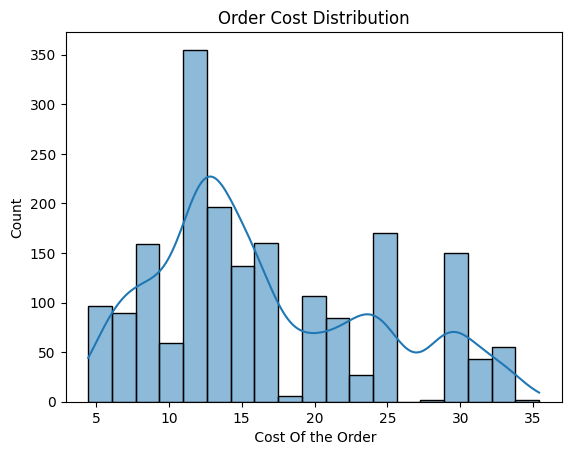

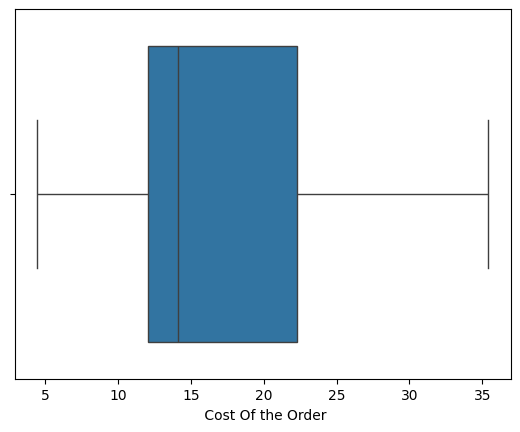

In [449]:
#Histogram visualizing the frequency distribution of  Cost Of the Order
plt.title("Order Cost Distribution")
sns.histplot(data=df, x='cost_of_the_order', kde=True)
plt.xlabel(" Cost Of the Order")
plt.show()
sns.boxplot(data=df, x='cost_of_the_order')
plt.xlabel(" Cost Of the Order")
plt.show()


**Observations**

*   Customer ordered Less expensive orders more than the expensive ones
*  The Histogram shows that it is right-skewed. Higher priced orders were placed less frequently.

* Boxplot shows the ranges for IQR, Q1 and Q3 and min and max  range for the oders.  There are no outliers point. 75% food order values are below 25$

**6. Day of the week**

In [450]:
## Average delivery_time based on day_of_the_week
mean_delivery_time = df.groupby('day_of_the_week')['delivery_time'].mean()
mean_delivery_time

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


**Observations:**

* The average delivery time on Weekday is 28.34 min whereas the weekend delivery time is 22.4 min. Weekday delivery takes 6 mins more than weekend.

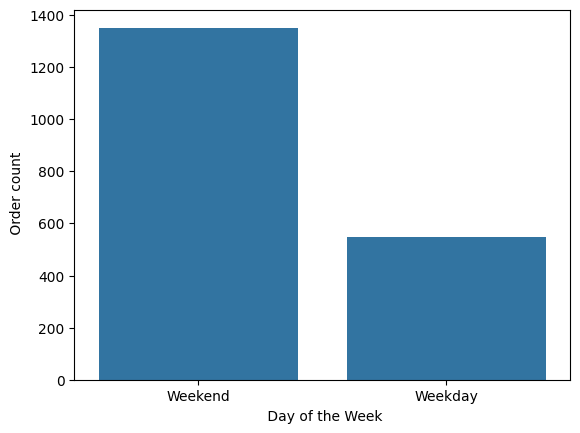

In [451]:

sns.countplot(data=df, x='day_of_the_week')
plt.xlabel(" Day of the Week")
plt.ylabel(" Order count")
plt.show()

**Observations:**

* Weekend orders are more than weekday orders.

**7.   Food Prepartion time**


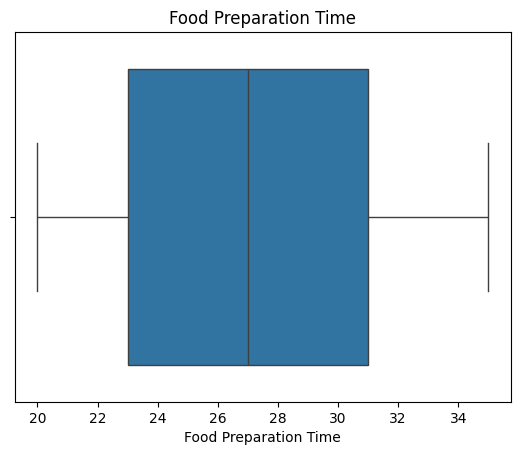

In [452]:


# Boxplot summary of the central tendency, variability, and skewness of the Food Preparation Time distribution

sns.boxplot(data=df, x='food_preparation_time')
plt.title("Food Preparation Time")
plt.xlabel("Food Preparation Time")

plt.show()

**Observations**

* Average time to prepare food is approximately 27 mins

* The preparation time ranges from a minimum of 20 minutes to a maximum of 35 minutes.


**8. Food Delivery Time**

Text(0, 0.5, 'Count')

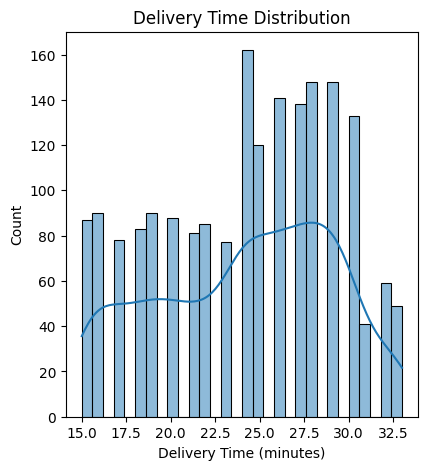

In [453]:
# Histogram visualizing the frequency distribution of delivery time

plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
sns.histplot(df['delivery_time'], kde=True, bins=30)
plt.title('Delivery Time Distribution')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Count')


##Observations

The histogram is skewed to the left and indicates that the food delivery time orders are clustered between 20 to 30 minutes with the highest occurance at 24 minutes.


More specific and complimentary information from the negatively scewed boxplot shows the middle 50% of the orders are delivered between 20 minutes and 28 minutes.

Overall, the combined visualizations suggest that the food aggregator company is generally efficient in delivering orders, with most being delivered within half an hour.

**9. Rating**

In [454]:
#Print the each unique value in the rating column and the frequency of each
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


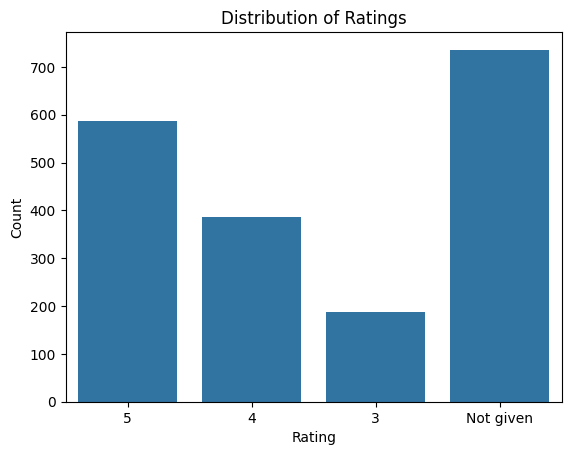

In [455]:

# distribution of ratings
sns.countplot(data=df, x='rating',  order=['5', '4', '3', 'Not given'])
plt.title('Distribution of Ratings')
plt.ylabel('Count')
plt.xlabel('Rating')
plt.show()

**Observations:**

*   Not given: This represents the number of orders that haven'treceived a rating. There are 736 such orders.

*   There are 588 orders with 5 rating. There are 386 orders with 4 rating. There are 188 orders with 3rating.




### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [456]:
# get the counts of resataurent names and select the top 5 from head
df_top_5_restaurent = df['restaurant_name'].value_counts().head(5)
df_top_5_restaurent

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68



* Top 5 Restaurents for the food oder are  "Shake Shack" followed by "The Meatball Shop", "Blue Ribbon Sushi", "Blue Ribbon Fried Chicken", and "Parm". "Shake Shack" is the most popular restaurant in this dataset with 219 orders,

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [457]:
# Filtering the cusine based on weekend using pandas where clause. getting the counts of it and selecting the first one from head
df_top_5_restaurent = df['cuisine_type'].where(df['day_of_the_week']=='Weekend').value_counts().head(1)
df_top_5_restaurent


,count
cuisine_type,
American,415


In [458]:
# Another way of getting the most popular cuisione based on weekend

# Filter the DataFrame to include only 'Weekends'
df_weekends = df[df['day_of_the_week'] == 'Weekend']

# Use value_counts() to find the frequency of each cuisine
cuisine_counts = df_weekends['cuisine_type'].value_counts()

# The most popular cuisine is the first item in the sorted index
most_popular_cuisine = cuisine_counts.index[0]
most_popular_cuisine

'American'


* American cuisine is most popular on Weekend.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [459]:
# Create a boolean mask: True for orders > $20
condition = df['cost_of_the_order']> 20

# calculate the percentagelculate
perecentage = (df[condition].shape[0]/df.shape[0])*100

print(perecentage)


29.24130663856691


In [460]:
# Create a boolean mask: True for orders > $20
orders_over_20_mask = df['cost_of_the_order'] > 20

# Count the number of True values (orders > $20)
# Summing a boolean Series counts the number of True values.
count_over_20 = orders_over_20_mask.sum()

# Get the total number of orders (total rows in the DataFrame)
total_orders = len(df)

# Calculate the percentage
percentage_over_20 = (count_over_20 / total_orders) * 100

print(f"Total orders: {total_orders}")
print(f"Orders costing more than $20: {count_over_20}")
print(f"Percentage of orders costing more than $20: {percentage_over_20 :.2f}%")

Total orders: 1898
Orders costing more than $20: 555
Percentage of orders costing more than $20: 29.24%



* Percentage of orders costing more than $20:  29.24%

### **Question 10**: What is the mean order delivery time? [1 mark]

In [461]:
# Write the code here
mean_delivery_time = df['delivery_time'].mean()
print(f"MImimum Delivery Time: {mean_delivery_time:.2f}")


MImimum Delivery Time: 24.16


* Minimum Delivery Time: 24.16

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [462]:

top_3_customers = df['customer_id'].value_counts().head(3)

df_top_3_customers = pd.DataFrame(top_3_customers)
df_top_3_customers

,count
customer_id,
52832,13
47440,10
83287,9



* The Customer Id of top three customer who placed most of the orders are 52832, 47440, 83287 and the number of orders are 13, 10, 9 respectively.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


**Delivery Time VS Day of the Week Distribution:**

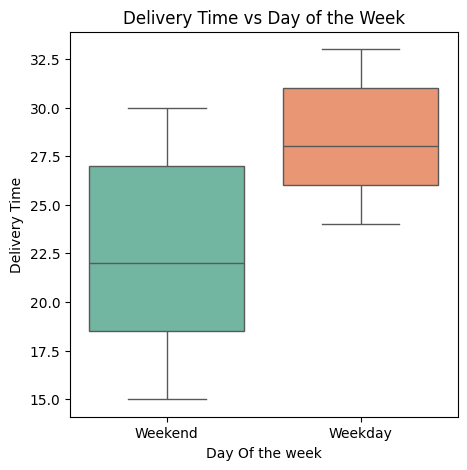

In [463]:
plt.figure(figsize=(5,5))
sns.boxplot(x = "day_of_the_week", y = "delivery_time", data = df, palette="Set2")
plt.title('Delivery Time vs Day of the Week')
plt.ylabel('Delivery Time')
plt.xlabel('Day Of the week')
plt.show()

**Observations:**

* On an average Weekend delivery time is less than Week Day orders.

**Cuisine Type Vs Week of the day**

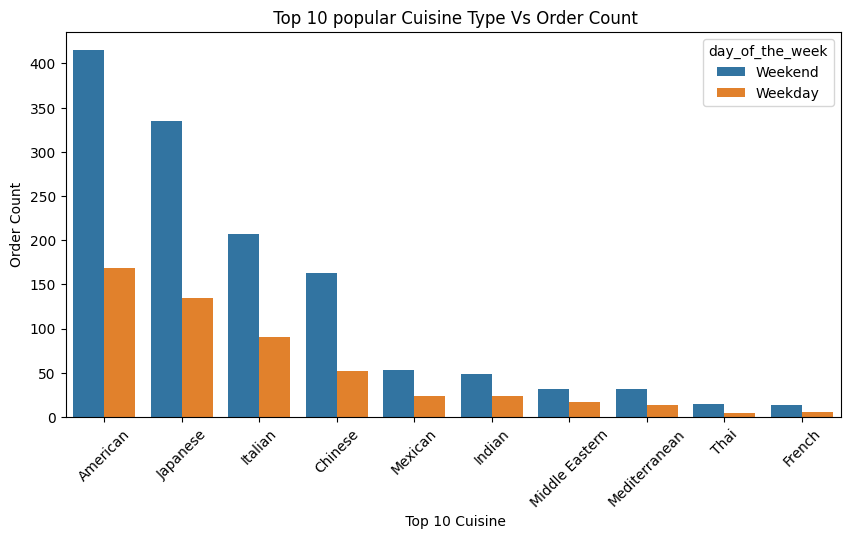

In [464]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='cuisine_type', order= df['cuisine_type'].value_counts().index[0:10],hue='day_of_the_week')
plt.title(" Top 10 popular Cuisine Type Vs Order Count")
plt.xlabel(" Top 10 Cuisine")
plt.ylabel("Order Count")
plt.xticks (rotation=45)
plt.show()

**Observations:**

* The most popular cuisine type, regardless of the day of the week, is "American" followed by "Japanese", "Italian" and "Chinese".

* Cusine Type observation shows similar pattern of having greater food orders on weekend than weekdays.


**Rating Vs Day of the Week**

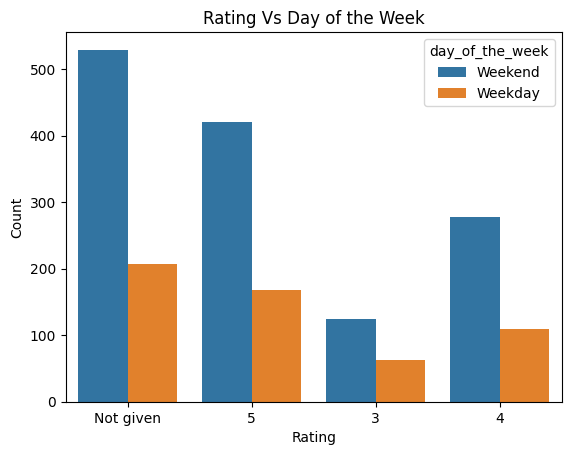

In [465]:
# distribution of ratings
sns.countplot(data=df, x='rating',  hue='day_of_the_week')
plt.title('Rating Vs Day of the Week')
plt.ylabel('Count')
plt.xlabel('Rating')
plt.show()

**Observations**

* Higher rating count is on weeknd than weekdays

* rating 3 count is the lowest.

* Not given rating count is the highest

**Cuisine vs Food Preparation Time**


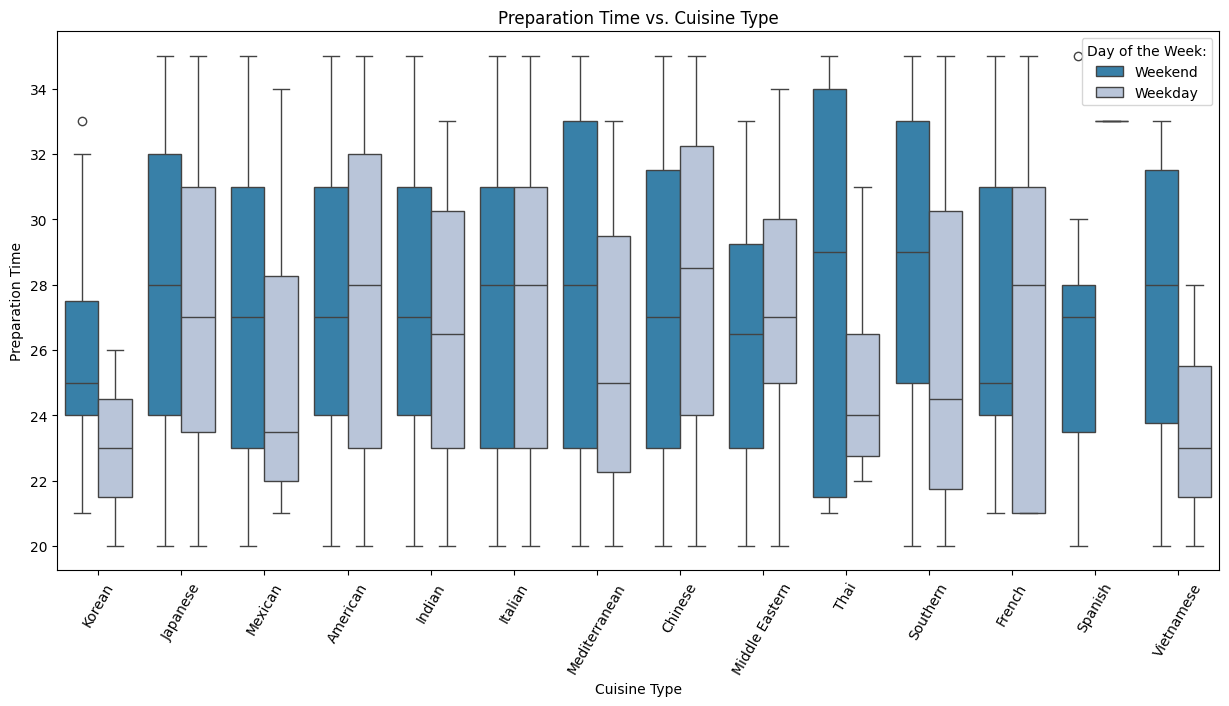

In [466]:
# Visualization of cuisines Types and food preparation time
plt.figure(figsize=(15,7))
sns.boxplot(x = "cuisine_type", y = "food_preparation_time", data = df,hue='day_of_the_week', palette = 'PuBu_r')
plt.title('Preparation Time vs. Cuisine Type')
leg = plt.legend(title='Day of the Week:')
plt.ylabel('Preparation Time')
plt.xlabel('Cuisine Type')
plt.xticks(rotation = 60)
plt.show()

**Observations:**

* Different cuisines exhibit distinct ranges in food preparation times. "Thai" show a broader range of preparation times compared to others.

* There is a significant diffrence between weekdays and weekends while others like "Italian" remaining relatively the same.
Korean cuisine type shows comparatively less preparation time and exhibit outliers.

**Restaurent Vs Rating**

Index(['Shake Shack', 'The Meatball Shop', 'Blue Ribbon Sushi',
       'Blue Ribbon Fried Chicken', 'Parm', 'RedFarm Broadway',
       'RedFarm Hudson', 'TAO', 'Han Dynasty',
       'Blue Ribbon Sushi Bar & Grill'],
      dtype='object', name='restaurant_name')


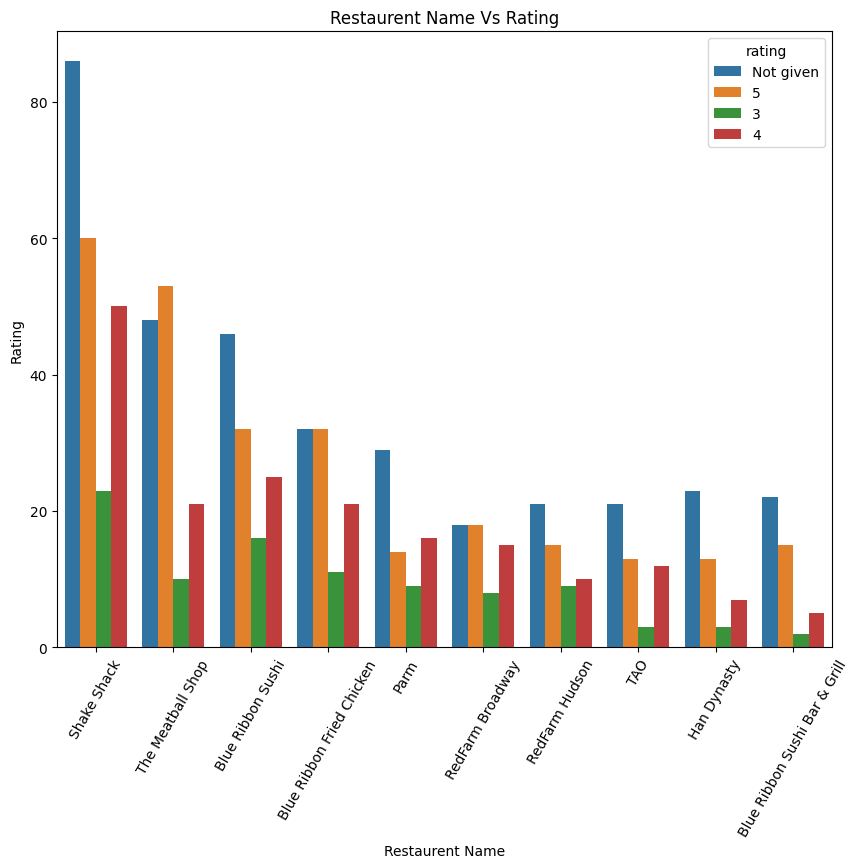

In [467]:
restaurent_list= df['restaurant_name'].value_counts().sort_values(ascending=False).index[0:10]
print(restaurent_list)
plt.figure(figsize=(10,8))
sns.countplot(x ='restaurant_name', data = df,hue='rating', order= restaurent_list)
plt.title('Restaurent Name Vs Rating')
plt.ylabel('Rating')
plt.xlabel('Restaurent Name')
plt.xticks(rotation = 60)
plt.show()

**Observations:**

* Shake Shack received the highest rating.
* The Meatball shop received second highest.
* TAO, HandDynasty did receive lowest rating.




**Cuisine Type vs Cost of the Order**

Index(['American', 'Japanese', 'Italian', 'Chinese', 'Mexican', 'Indian',
       'Middle Eastern', 'Mediterranean', 'Thai', 'French', 'Southern',
       'Korean', 'Spanish', 'Vietnamese'],
      dtype='object', name='cuisine_type')


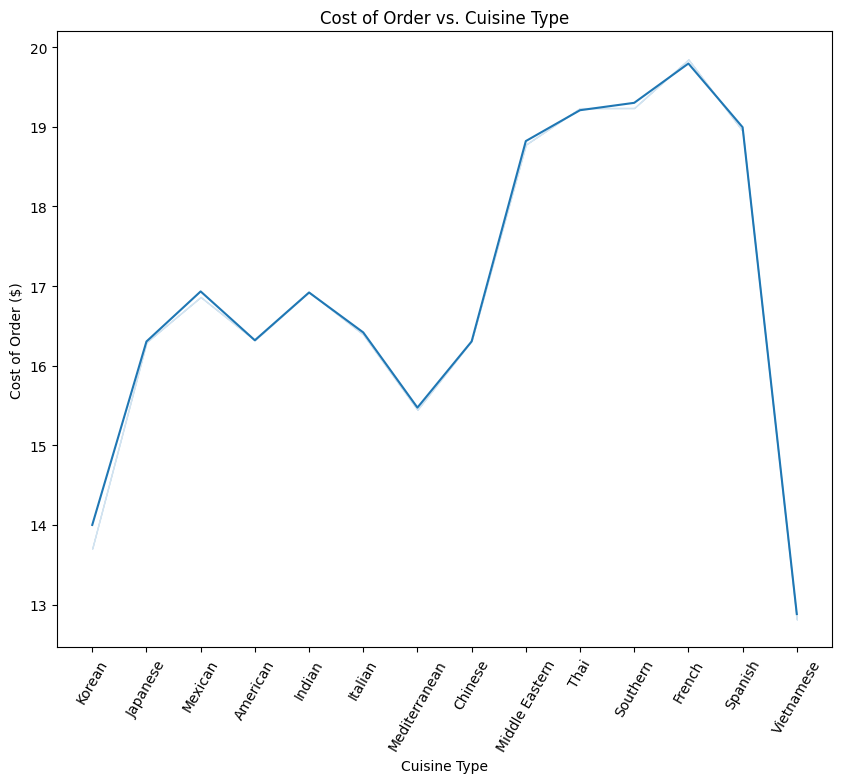

In [468]:
#T Visualize the relationship between cost of the order and cuisine type

cuisine_list= df['cuisine_type'].value_counts().sort_values(ascending=False).index[0:14]
print(cuisine_list)
plt.figure(figsize=(10,8))
#sns.countplot(x = "cuisine_type", data = df,hue='cost_of_the_order', order=cuisine_list)
sns.lineplot(data = df , y = 'cost_of_the_order' , x = 'cuisine_type', errorbar=('ci', False) );
plt.title('Cost of Order vs. Cuisine Type')
plt.ylabel('Cost of Order ($)')
plt.xlabel('Cuisine Type')
plt.xticks(rotation = 60)
plt.show()

**Observations:**

* There is a wide variability in order costs and median cost across different cuisine types
* Vietnamese having the lowest order costs. French cusine is of  highest cost.

**Average Order Cost by Cuisine and Day of Week**

--- Resulting Pivot Table (Average Order Cost) ---
day_of_the_week    Weekday    Weekend
cuisine_type                         
American         15.308343  16.731735
Chinese          17.147692  16.036442
French           20.866000  19.381538
Indian           17.162500  16.800816
Italian          16.890110  16.211449
Japanese         16.368074  16.278925
Korean           12.180000  14.332727
Mediterranean    14.040000  16.102500
Mexican          16.555833  17.103962
Middle Eastern   19.832941  18.282812
Southern         19.226667  19.340909
Spanish          12.130000  19.618182
Thai             15.462500  20.206667
Vietnamese       11.916667  13.607500


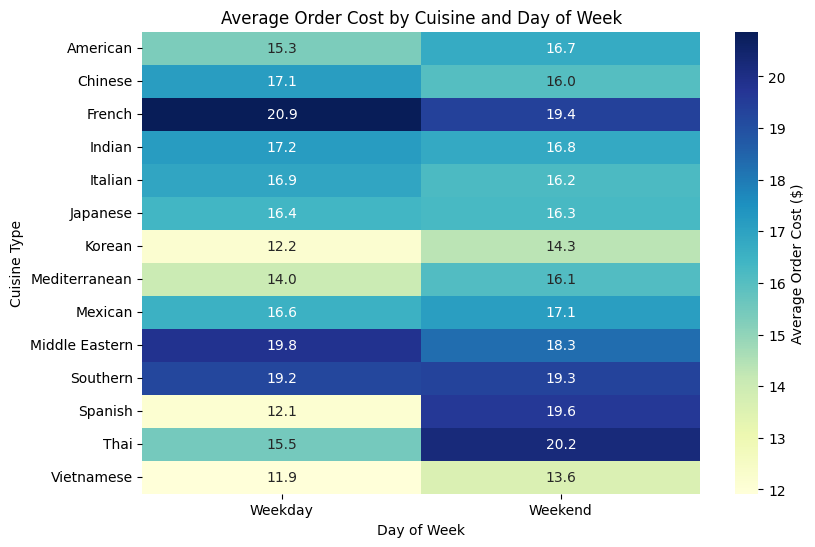

In [469]:
# --- Create the Pivot Table (Data Aggregation) ---
# We calculate the mean (average) 'Order_Cost' for each combination of 'Cuisine' and 'Day_of_Week'.

# index=Rows, columns=Columns, values=The measurement, aggfunc=The aggregation (mean)
pivot_df = df.pivot_table(
    index='cuisine_type',
    columns='day_of_the_week',
    values='cost_of_the_order',
    aggfunc='mean'
)

print("--- Resulting Pivot Table (Average Order Cost) ---")
print(pivot_df)

# --- Heatmap (Visualization) ---

plt.figure(figsize=(9, 6))
sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Average Order Cost ($)'}
)

plt.title('Average Order Cost by Cuisine and Day of Week')
plt.ylabel('Cuisine Type')
plt.xlabel('Day of Week')
plt.show()


**Observations:**

* This observation does not show consitency on how pricing paterns between weekdays and weeknds.
Thai, Spanish, Vietnamese, Mediterranean, american costs more on weekend.

* Vietnamese, Korean are the cheapest food option. Frech food is costliest.

**Food Preparation Time and Cost of Order**

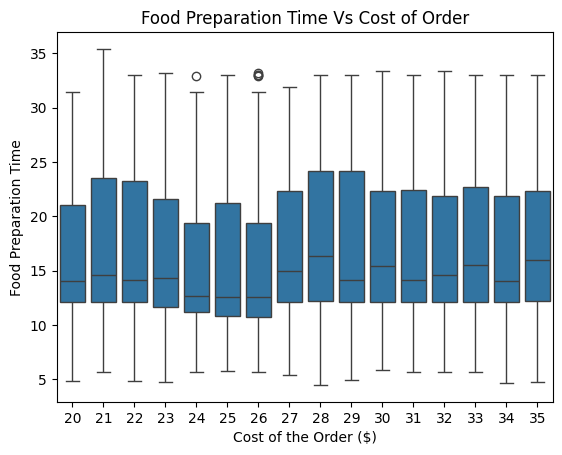

In [470]:
sns.boxplot(data=df, x='food_preparation_time', y='cost_of_the_order');
plt.title('Food Preparation Time Vs Cost of Order')
plt.ylabel('Food Preparation Time')
plt.xlabel('Cost of the Order ($)')
plt.show()

**Heatmap to display the correlation of all numeric columns**

* Since rating column has huge no of 'Not given' rating.
Filter out the 'Not Given' rows and then convert this column type to int64.

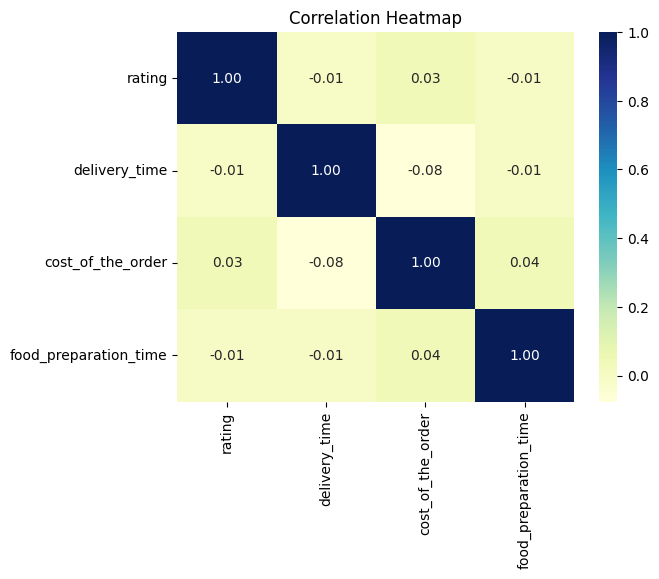

In [471]:
# Corrleation of all numeric columns.

# Filter out the rated restaurants. and this will not have any 'Not given' values
df_with_rating = df[df['rating'] != 'Not given'].copy()

# Convert rating column from object to integer
df_with_rating['rating'] = df_with_rating['rating'].astype('int')

#df_corr= df.select_dtypes(include ='number').corr()

columns_to_correlate = ['rating', 'delivery_time', 'cost_of_the_order', 'food_preparation_time']

# Select the columns from the DataFrame and then apply .corr()
df_corr = df_with_rating[columns_to_correlate].corr()

sns.heatmap(data=df_corr, annot=True, cmap= 'YlGnBu', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()



**Observations:**

* For the rating column which is of type Object was converted to numeric column, by first removing the ' Not given' rating and then coveted to int type column

There are no significant correlations between the numerical values.

**Rating vs Food Preparation Time**

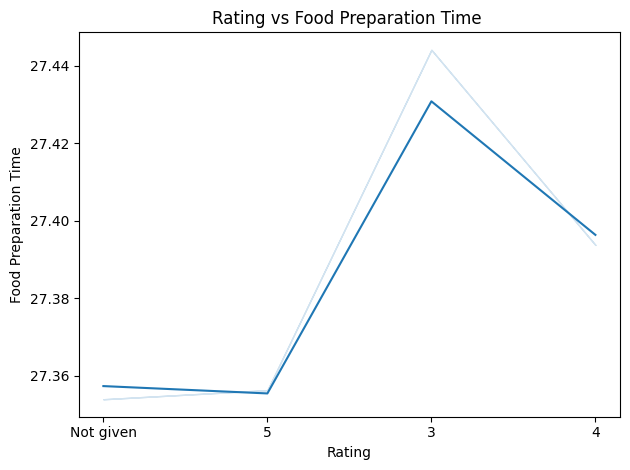

In [472]:
# Rating vs Food Preparation Time

sns.lineplot(data = df , y = 'food_preparation_time' , x = 'rating', errorbar=('ci', False) );
plt.title('Rating vs Food Preparation Time ')
plt.xlabel('Rating')
plt.ylabel('Food Preparation Time')
plt.tight_layout()
plt.show()

**Observations**


* Food with a rating of 5 seems to have the shortest average preparation time and there's a slight increase in preparation time for foods with a rating of 3 compared to 5 or 4, on weekends especially.

**Cost of Order Vs Food Preparation Time**

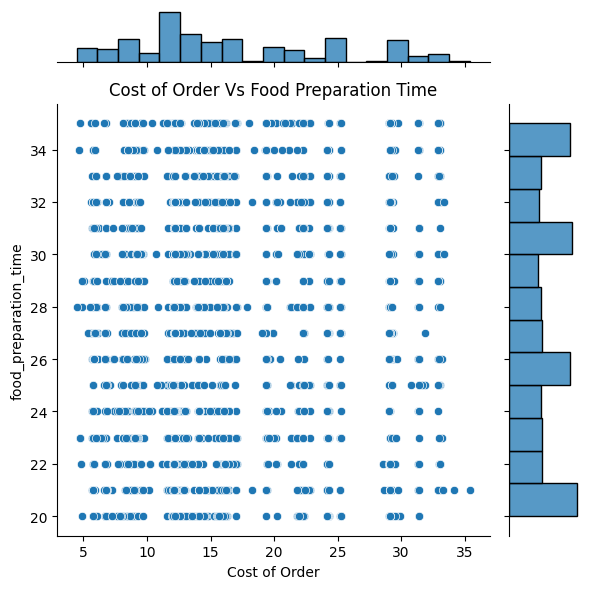

In [473]:
sns.jointplot(data=df, x='cost_of_the_order', y='food_preparation_time');
plt.title('Cost of Order Vs Food Preparation Time')
plt.xlabel('Cost of Order')
plt.ylabel('food_preparation_time')
plt.tight_layout()
plt.show()

**Rating vs Cost of Order**

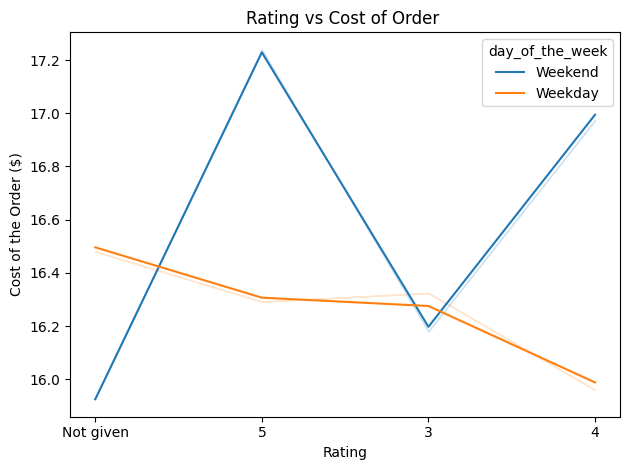

In [474]:
# Rating vs Cost of Order Vs Day of the Week

sns.lineplot(data = df , y = 'cost_of_the_order' , x = 'rating', errorbar=('ci', False),hue='day_of_the_week' );
plt.title('Rating vs Cost of Order ')
plt.xlabel('Rating')
plt.ylabel('Cost of the Order ($)')
plt.tight_layout()
plt.show()

**Observations:**

* On the weekend Rating seems to be decreasing with cost.


**Pairplot of all numerical columns**

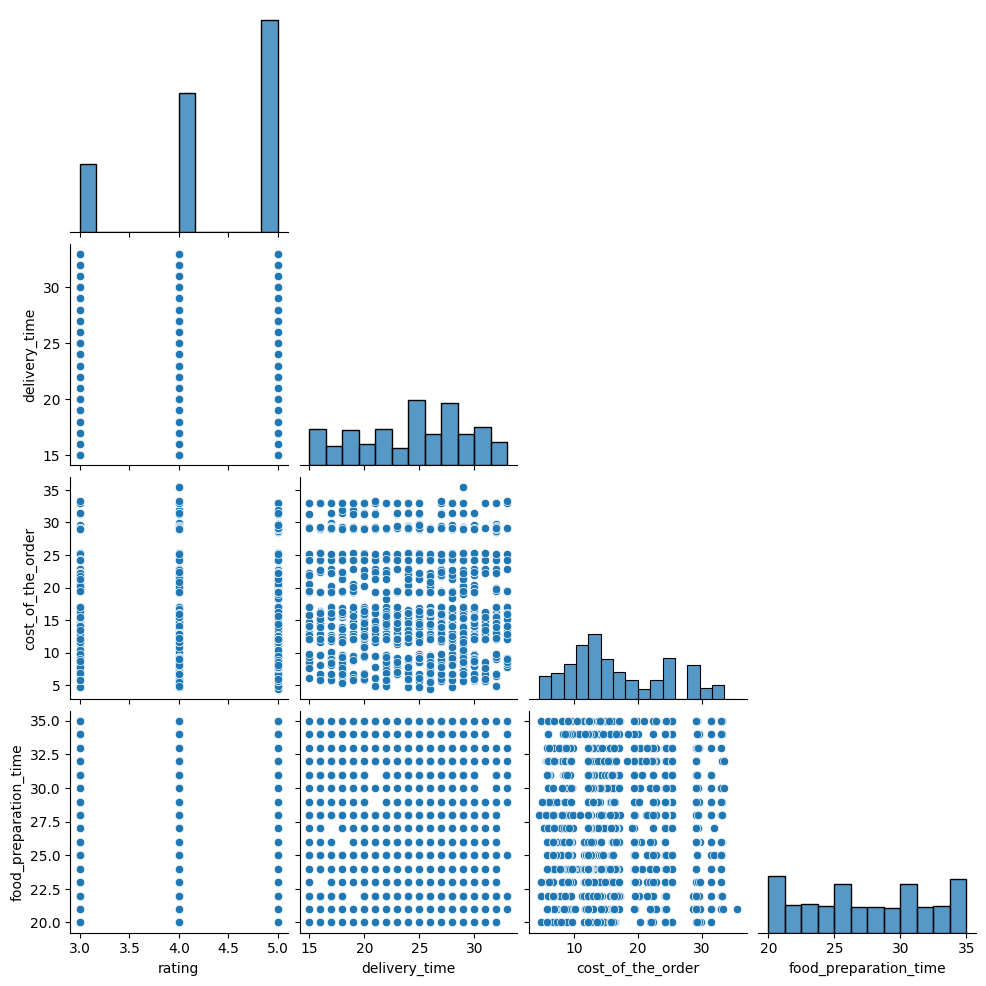

In [475]:

# Filter out the rated restaurants. and this will not have any 'Not given' values
df_with_rated= df[df['rating'] != 'Not given'].copy()

# Convert rating column from object to integer
df_with_rated['rating'] = df_with_rated['rating'].astype('int')

'''sns.scatterplot(
    x='delivery_time',
    y='cost_of_the_order',
             # Uses color gradient based on rating magnitude
    data=df_rated1,
    palette='viridis'         # Use a sequential color map
) '''

cols = ['rating', 'delivery_time', 'cost_of_the_order', 'food_preparation_time']
sns.pairplot(df_with_rated[cols], corner=True)

plt.show()

**Observations:**

* This Pairplot observation does not provide clear indication of the anything.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [476]:

# Define the threshold variables
MIN_RATING_COUNT = 50
MIN_AVG_RATING = 4.0

# Filter out the rated restaurants. and this will not have any 'Not given' values
df_rated = df[df['rating'] != 'Not given'].copy()

# Convert rating column from object to integer
df_rated['rating'] = df_rated['rating'].astype('int')

print("Data type of rating column :", df_rated['rating'].dtype)

# original DataFrame rating column still has 'Not given' values
df['rating'].value_counts()

# Create a dataframe with restaurant names and their rating counts
df_rating_count = df_rated.groupby(['restaurant_name'])['rating'].count().sort_values(ascending = False).reset_index()


# find the restaurents that has rating > 50
df_restaurents = df_rating_count[df_rating_count['rating'] > MIN_RATING_COUNT]
restaurent_names = df_restaurents['restaurant_name']

# Filter out the restaurants that have rating count more than 50
df_restaurents_rating_over50= df_rated[df_rated['restaurant_name'].isin(restaurent_names)].copy()


# Group the restaurant names with their ratings and find the mean rating of each restaurant
df_rating_over50_mean = df_restaurents_rating_over50.groupby(['restaurant_name'])['rating'].mean().sort_values(ascending = False).reset_index()

# find out the restaurents having rating count over 50 and rating average > 4
df_final = df_rating_over50_mean[df_rating_over50_mean['rating']>4]
df_final



Data type of rating column : int64


,restaurant_name,rating
0,The Meatball Shop,4.511905
1,Blue Ribbon Fried Chicken,4.328125
2,Shake Shack,4.278195
3,Blue Ribbon Sushi,4.219178


**Observations:**

* The restaurants selected for the promotional marketing offer, due to their high rating counts and high average customer ratings, are The Meatball Shop (with the highest average rating of 4.5), followed by Blue Ribbon Fried Chicken, Shake Shack, and Blue Ribbon Sushi.



### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [477]:

# find out the orders that cost > 60 and do the sum total of cost for these orders and add 25% on top of it
cost_over20 = df[df['cost_of_the_order'] > 20]['cost_of_the_order'].sum()
print(" Total cost of orders over 20 :", cost_over20)

revenue_over20 = cost_over20*0.25
print(" Revenue of orders over $20:", revenue_over20)

# find out the orders that cost > 5 but less than 20  and do the sum total of cost for these orders and add 15% on top of it
cost_over5 = df[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] < 20 )]['cost_of_the_order'].sum()
print( " \nTotal cost of orders over 5 :", cost_over5)

revenue_over5 = cost_over5*0.15
print(" Revenue of orders over $5:", revenue_over5)

#cost_less5 = df[df['cost_of_the_order'] <= 5]['cost_of_the_order'].sum()

print( f" \n Total Revenue of orders :  ${revenue_over5+revenue_over20:.2f}")


 Total cost of orders over 20 : 14754.91
 Revenue of orders over $20: 3688.7275
 
Total cost of orders over 5 : 16517.170000000002
 Revenue of orders over $5: 2477.5755000000004
 
 Total Revenue of orders :  $6166.30


**Observations:**

* Total Revenue of orders : $6166.30





### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [478]:

# Create a new 'total_food_delivery_time' column in the dataframe
df['total_food_delivery_time'] = df['delivery_time'] + df['food_preparation_time']

# Filter out the orders that have a total_time > 60 minutes
df_food_delivery_over60m = df[df['total_food_delivery_time']> 60]

# The percentage of such orders in the dataset
percentage = df_food_delivery_over60m.shape[0]/df.shape[0]*100

print(f"Percentage of orders that take more than 60 minutes to get delivered: {percentage:.2f}%")

Percentage of orders that take more than 60 minutes to get delivered: 10.54%


**Observations:**

* Percentage of the orders that take more than 60 minutes: 10.54 %

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [479]:
# Average delivery time by day of the week
delivery_by_day = df.groupby('day_of_the_week')['delivery_time'].mean().sort_values()
delivery_by_day

,delivery_time
day_of_the_week,
Weekend,22.470022
Weekday,28.340037


**Observations:**

* Weekend Delivery time is 6 minutes faster in the weekday delivery. 22.5 min for Weekend and 28.3 min for weekdays. Hence orders are higher during the weekend than weekdays.

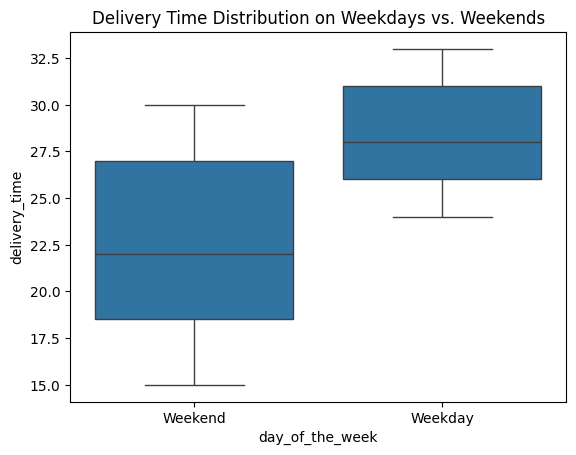

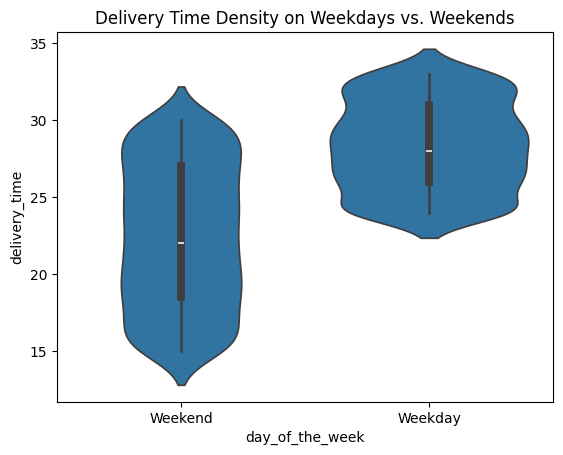

In [480]:


sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)
plt.title('Delivery Time Distribution on Weekdays vs. Weekends')
plt.show()


sns.violinplot(x='day_of_the_week', y='delivery_time', data=df)
plt.title('Delivery Time Density on Weekdays vs. Weekends')
plt.show()

**Observations:**

* Weekend Delivery time is 6 minutes faster in the weekday delivery. 22.5 min for Weekend and 28.3 min for weekdays. Hence orders are higher during the weekend than weekdays.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

**Conclusions:**

* The dataset consists of 1898 rows and 9 columns.

*  Total time taken for the food deliec=very including the preparation: On average, food preparation List item takes approximately 27.37 min, and delivery takes about 24.16 min. Total average total time it takes 51.53 min.

*  Shake Shack, The Meatball Shop, and Blue Ribbon Sushi are the top 3 restaurants in terms of the number of orders they receive.

* The Meatball Shop has the highest average rating, followed closely by Blue Ribbon Fried Chicken and Shake Shack.

*  Revenue: The company has generated a revenue of approximately $6166.3 through its commission model.

*  About 29.24% of orders cost more than 20 dollars. The average cost of an order is $16.50.

*  Weekend Delivery time is 6 minutes faster in the weekday delivery. 22.5 min for Weekend and 28.3 min for weekdays.



**Recommendations:**

* American cuisine seems to be the most popular, especially on weekends, the company can consider partnering with more restaurants offering this cuisine or promote existing ones with special weekend deals.

* Since food orders are generated more on weekend. Company should accomodoate greater number of delivery persons for weekend delivery.

* Company should promote the top restaurents that generate more orders and also having good customer rating like Shake Shack and The Meatball Shop, which have high order counts and good ratings. Also can provide them special deals or loyalty programs.

* A significant number of orders remain unrated. Introducing an incentive program could encourage more customers to leave reviews, providing valuable feedback that can guide the business toward meaningful improvements.

* For customers who order more frequently, the company should consider offering special discounts or savings programs to encourage continued and increased purchases.









---